In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
!pip install panda

In [3]:
data = pd.read_csv('../artifacts/Combined Data.csv')

In [4]:
data.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


### Data Preprocessing

In [5]:
data.shape

(53043, 3)

In [6]:
data.isnull().sum()

Unnamed: 0      0
statement     362
status          0
dtype: int64

In [7]:
data = data.dropna()

In [8]:
data.isnull().sum()

Unnamed: 0    0
statement     0
status        0
dtype: int64

In [9]:
data.shape

(52681, 3)

In [10]:
data.duplicated().sum()

np.int64(0)

### Text Preprocessing

In [11]:
import re
import string

In [12]:
data["statement"].head(5)

0                                           oh my gosh
1    trouble sleeping, confused mind, restless hear...
2    All wrong, back off dear, forward doubt. Stay ...
3    I've shifted my focus to something else but I'...
4    I'm restless and restless, it's been a month n...
Name: statement, dtype: object

##### Convert uppercase to lowercase

In [13]:
data["statement"] = data["statement"].astype(str).apply(lambda x: " ".join(word.lower() for word in x.split()))


In [14]:
data["statement"].head(5)

0                                           oh my gosh
1    trouble sleeping, confused mind, restless hear...
2    all wrong, back off dear, forward doubt. stay ...
3    i've shifted my focus to something else but i'...
4    i'm restless and restless, it's been a month n...
Name: statement, dtype: object

##### Remove Links

In [15]:
data["statement"] = data["statement"].astype(str).apply(
    lambda x: " ".join(re.sub(r'https?://\S+|www\.\S+', '', word)for word in x.split()))

##### Remove punctuation

In [16]:
data["statement"] = data["statement"].astype(str).apply(
    lambda x: x.translate(str.maketrans('', '', string.punctuation)))

In [17]:
data["statement"].head(5)

0                                           oh my gosh
1    trouble sleeping confused mind restless heart ...
2    all wrong back off dear forward doubt stay in ...
3    ive shifted my focus to something else but im ...
4    im restless and restless its been a month now ...
Name: statement, dtype: object

##### Remove numbers

In [18]:
data["statement"] = data["statement"].astype(str).apply(
    lambda x: re.sub(r'\d+', '', x))

##### Remove Stopping words

In [19]:
!pip install nltk

In [20]:
import nltk

with open('../static/model/nltk_data/corpora/stopwords/english', 'r') as file:
    sw = file.read().splitlines()

In [21]:
data["statement"] = data["statement"].astype(str).apply(
    lambda x: " ".join(word for word in x.split() if word.lower() not in sw))

In [22]:
data.head(5)

,Unnamed: 0,statement,status
0,0,oh gosh,Anxiety
1,1,trouble sleeping confused mind restless heart ...,Anxiety
2,2,wrong back dear forward doubt stay restless re...,Anxiety
3,3,ive shifted focus something else im still worried,Anxiety
4,4,im restless restless month boy mean,Anxiety


##### Stemming

In [23]:
from nltk.stem import PorterStemmer
ps = PorterStemmer()

In [24]:
data["statement"] = data["statement"].astype(str).apply(
    lambda x: " ".join(ps.stem(x) for x in x.split()))

In [25]:
data

,Unnamed: 0,statement,status
0,0,oh gosh,Anxiety
1,1,troubl sleep confus mind restless heart tune,Anxiety
2,2,wrong back dear forward doubt stay restless re...,Anxiety
3,3,ive shift focu someth els im still worri,Anxiety
4,4,im restless restless month boy mean,Anxiety
...,...,...,...
53038,53038,nobodi take serious i’v dealt depressionanxiet...,Anxiety
53039,53039,selfish dont feel good like dont belong world ...,Anxiety
53040,53040,way sleep better cant sleep night med didnt help,Anxiety
53041,53041,public speak tip hi give present work next wee...,Anxiety


#### Building Vacabulary

In [26]:
from collections import Counter
vocab = Counter()

In [27]:
for sentence in data["statement"]:
    vocab.update(sentence.split())

In [28]:
vocab

Counter({'feel': 45566,
         'like': 39643,
         'want': 33648,
         'get': 29366,
         'go': 26295,
         'know': 25546,
         'life': 22314,
         'time': 21284,
         'even': 18950,
         'think': 17575,
         'peopl': 16855,
         'would': 16798,
         'year': 16564,
         'day': 16479,
         'realli': 16370,
         'thing': 16281,
         'one': 15528,
         'tri': 15435,
         'make': 15407,
         'cannot': 15393,
         'depress': 14412,
         'im': 13829,
         'help': 13542,
         'work': 13456,
         'friend': 13191,
         'take': 11911,
         'much': 11844,
         'never': 11765,
         'live': 11616,
         'start': 10477,
         'fuck': 10425,
         'could': 9791,
         'need': 9763,
         'thought': 9678,
         'back': 9437,
         'anymor': 9409,
         'anxieti': 9279,
         'talk': 9264,
         'see': 9106,
         'way': 8949,
         'anyth': 8947,
         's

In [29]:
len(vocab)

61185

In [30]:
tokens = [key for key in vocab if vocab[key]>10]

In [31]:
len(tokens)

7247

In [32]:
def save_vocabulary(lines,filename):
    data = '\n'.join(lines)
    file = open(filename,'w',encoding="utf-8")
    file.write(data)
    file.close()

save_vocabulary(tokens, '../static/model/vocablary.txt')

#### Divide Dataset

In [33]:
data

,Unnamed: 0,statement,status
0,0,oh gosh,Anxiety
1,1,troubl sleep confus mind restless heart tune,Anxiety
2,2,wrong back dear forward doubt stay restless re...,Anxiety
3,3,ive shift focu someth els im still worri,Anxiety
4,4,im restless restless month boy mean,Anxiety
...,...,...,...
53038,53038,nobodi take serious i’v dealt depressionanxiet...,Anxiety
53039,53039,selfish dont feel good like dont belong world ...,Anxiety
53040,53040,way sleep better cant sleep night med didnt help,Anxiety
53041,53041,public speak tip hi give present work next wee...,Anxiety


In [34]:
X = data["statement"]
Y = data["status"]

In [35]:
!pip install sklearn-model

In [36]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2)

In [37]:
X_train.shape

(42144,)

In [38]:
X_test.shape

(10537,)

In [39]:
Y_train

37094      Suicidal
9234       Suicidal
37713    Depression
29016        Stress
5015         Normal
            ...    
19149    Depression
2108         Normal
24749    Depression
44137        Normal
14103      Suicidal
Name: status, Length: 42144, dtype: object

In [40]:
X_train

37094    gener shit what fuck point life liter incap ac...
9234         look fast effect way end idea fast effect way
37713    regret back commit suicid pretti often done th...
29016    live mom right cannot afford find new place we...
5015     valid infoaeid alfitr fall red daymerdeka ªðÿ‡...
                               ...                        
19149    feel like never abl sit front counselor alway ...
2108                                             mila kebo
24749    cannot find motiv finish schoolwork assign fin...
44137    duskyazur least u got lie bn way long mr woke ...
14103    end life sunday date adjust go post want share...
Name: statement, Length: 42144, dtype: object

#### Vecorization

In [41]:
def vectorizer(ds, vocabulary):
    vectorized_lst = []

    for sentence in ds:
        sentence_lst = np.zeros(len(vocabulary))

        for i in range(len(vocabulary)):
            if vocabulary[i] in sentence.split():
                sentence_lst[i] = 1

        vectorized_lst.append(sentence_lst)

    vectorized_lst_new = np.asarray(vectorized_lst, dtype = np.float32)

    return vectorized_lst_new

In [ ]:
vectorized_x_train = vectorizer(X_train, tokens)

In [43]:
vectorized_x_test = vectorizer(X_test, tokens)

In [44]:
Y_test.value_counts()

status
Normal                  3225
Depression              3137
Suicidal                2121
Anxiety                  769
Bipolar                  539
Stress                   522
Personality disorder     224
Name: count, dtype: int64

In [45]:
Y_train.value_counts()

status
Normal                  13118
Depression              12267
Suicidal                 8531
Anxiety                  3072
Bipolar                  2238
Stress                   2065
Personality disorder      853
Name: count, dtype: int64

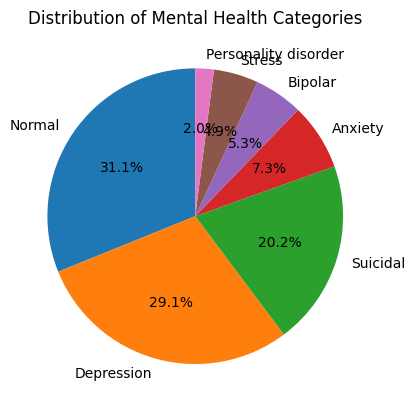

In [46]:
values = np.array([
    Y_train.value_counts()["Normal"],
    Y_train.value_counts()["Depression"],
    Y_train.value_counts()["Suicidal"],
    Y_train.value_counts()["Anxiety"],
    Y_train.value_counts()["Bipolar"],
    Y_train.value_counts()["Stress"],
    Y_train.value_counts()["Personality disorder"]
])

labels = [
    "Normal",
    "Depression",
    "Suicidal",
    "Anxiety",
    "Bipolar",
    "Stress",
    "Personality disorder"
]

plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Distribution of Mental Health Categories")
plt.show()

#### Handle Imbalanced dataset

In [47]:
!pip install imbalanced-learn

In [48]:
pip install imblearn



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\ASUS\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [49]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()
vectorized_x_train_smote, y_train_smote = smote.fit_resample(vectorized_x_train, Y_train)
print(vectorized_x_train_smote.shape, y_train_smote.shape)

(91826, 7247) (91826,)


In [50]:
y_train_smote.value_counts()

status
Suicidal                13118
Depression              13118
Stress                  13118
Normal                  13118
Bipolar                 13118
Anxiety                 13118
Personality disorder    13118
Name: count, dtype: int64

In [51]:
y_train_smote

0          Suicidal
1          Suicidal
2        Depression
3            Stress
4            Normal
            ...    
91821      Suicidal
91822      Suicidal
91823      Suicidal
91824      Suicidal
91825      Suicidal
Name: status, Length: 91826, dtype: object

#### Model training and Evaluation

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [53]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def training_scores(y_act, y_pred):
    acc = round(accuracy_score(y_act, y_pred), 3)
    pr = round(precision_score(y_act, y_pred, average='weighted'), 3)
    rec = round(recall_score(y_act, y_pred, average='weighted'), 3)
    f1 = round(f1_score(y_act, y_pred, average='weighted'), 3)
    print(f'Training Scores:\n\tAccuracy = {acc}\n\tPrecision = {pr}\n\tRecall = {rec}\n\tF1-Score = {f1}')

def validation_scores(y_act, y_pred):
    acc = round(accuracy_score(y_act, y_pred), 3)
    pr = round(precision_score(y_act, y_pred, average='weighted'), 3)
    rec = round(recall_score(y_act, y_pred, average='weighted'), 3)
    f1 = round(f1_score(y_act, y_pred, average='weighted'), 3)
    print(f'Testing Scores:\n\tAccuracy = {acc}\n\tPrecision = {pr}\n\tRecall = {rec}\n\tF1-Score = {f1}')


In [54]:
vectorized_x_train_smote

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(91826, 7247), dtype=float32)

In [55]:
vectorized_x_train_smote = vectorized_x_train_smote.astype('float32')
vectorized_x_test = vectorized_x_test.astype('float32')

#### Logistic Regression

#### Naive Bayes

In [ ]:
rf = RandomForestClassifier()
rf.fit(vectorized_x_train_smote, y_train_smote)

y_train_pred = rf.predict(vectorized_x_train_smote)

y_test_pred = rf.predict(vectorized_x_test)

training_scores(y_train_smote, y_train_pred)

validation_scores(Y_test, y_test_pred)   

In [ ]:
mnb = MultinomialNB()
mnb.fit(vectorized_x_train_smote, y_train_smote)

y_train_pred = mnb.predict(vectorized_x_train_smote)

y_test_pred = mnb.predict(vectorized_x_test)

training_scores(y_train_smote, y_train_pred)

validation_scores(Y_test, y_test_pred)

In [ ]:
ds = DecisionTreeClassifier()
ds.fit(vectorized_x_train_smote, y_train_smote)

y_train_pred = ds.predict(vectorized_x_train_smote)

y_test_pred = ds.predict(vectorized_x_test)

training_scores(y_train_smote, y_train_pred)

validation_scores(Y_test, y_test_pred)

In [ ]:
import pickle

with open('../static/model/model.pickle', 'wb') as file:
    pickle.dump(ds,file)

In [ ]:
lr = LogisticRegression()
lr.fit(vectorized_x_train_smote, y_train_smote)

y_train_pred = lr.predict(vectorized_x_train_smote)

y_test_pred = lr.predict(vectorized_x_test)

training_scores(y_train_smote, y_train_pred)

validation_scores(Y_test, y_test_pred)   

#### Model File Building